# Part 24: Retrieval-Augmented Generation — Building the Full Pipeline

Track C moves from building and serving models to building **applications** on them. The first
question any application hits: the model does not know your data.

Three options exist, and choosing between them is the first real design decision.

| Approach | Good for | Costs |
|---|---|---|
| **Fine-tuning** | Teaching *behaviour*, style, format, domain vocabulary | Retraining per update; poor at factual recall; no attribution |
| **Long context** | Small, stable corpora that fit in the window | Quadratic cost; "lost in the middle"; expensive per query |
| **RAG** | Large, changing corpora needing attribution | Pipeline complexity; retrieval failures; more moving parts |

The common mistake is using fine-tuning for knowledge. Fine-tuning is good at teaching a model
*how* to behave and unreliable at teaching it *what is true* — facts learned this way are diffuse,
hard to update, and impossible to cite. **RAG puts the facts in the context window, where the
model is best at using them and where you can point at the source.**

This notebook builds every stage from scratch: chunking, embedding, vector search, BM25, hybrid
fusion, reranking, and evaluation.

In [1]:
import math
import re
import sys
import time
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.insert(0, '..')

torch.manual_seed(0)

## 1. A corpus and a set of questions

To evaluate retrieval we need documents and questions with **known** correct sources. We build a
small synthetic knowledge base where ground truth is unambiguous — that is what makes the metrics
in section 8 meaningful.

In [2]:
DOCUMENTS = [
    ("transformers", """
The Transformer architecture was introduced in 2017 in the paper Attention Is All You Need.
It replaced recurrence with self-attention, which allows every token to attend to every other
token in parallel. This parallelism is what made training on very large corpora practical.
The original model was an encoder-decoder designed for machine translation.
"""),
    ("attention", """
Scaled dot-product attention computes a weighted sum of value vectors. The weights come from
the dot product of queries and keys, divided by the square root of the head dimension. That
division keeps the softmax in a well-conditioned range as dimension grows. Multi-head attention
runs several such operations in parallel subspaces and concatenates the results.
"""),
    ("positional", """
Attention is permutation-invariant, so position must be injected explicitly. The original paper
used fixed sinusoidal encodings added to the token embeddings. Modern models use rotary position
embeddings, known as RoPE, which rotate query and key vectors by an angle proportional to
position. The resulting dot product depends only on relative offset.
"""),
    ("normalization", """
Layer normalization stabilizes training by normalizing activations per token. RMSNorm is a
cheaper variant that omits the mean-centering step and keeps only re-scaling. Pre-norm
placement, where normalization comes before each sublayer, makes deep stacks trainable without
elaborate warmup schedules.
"""),
    ("moe", """
Mixture-of-Experts replaces a single feed-forward network with many experts and routes each
token to only a few. This decouples parameter count from per-token compute. The central
difficulty is load balancing: without intervention the router collapses onto a few favourite
experts. DeepSeek-V3 uses a loss-free bias adjustment scheme instead of an auxiliary loss.
"""),
    ("quantization", """
Quantization stores weights in fewer bits. Per-channel scales beat per-tensor scales because a
single outlier channel no longer inflates the scale for everything else. Activations are harder
to quantize than weights because they contain systematic outlier channels. SmoothQuant migrates
that difficulty from activations into weights by exact rescaling.
"""),
    ("kvcache", """
During autoregressive generation the keys and values of earlier tokens never change, so caching
them avoids recomputation. The KV cache makes generating each token linear rather than quadratic
work. Its size scales with batch size, sequence length, layer count, and the number of key-value
heads, which is what grouped-query attention shrinks.
"""),
    ("serving", """
PagedAttention manages the KV cache in fixed-size blocks with a block table, the way an
operating system manages virtual memory. This bounds internal fragmentation to one partial block
per sequence. Continuous batching schedules at iteration granularity so finished sequences leave
the batch immediately and waiting requests join.
"""),
    ("training", """
AdamW is the standard optimizer for Transformers, combining Adam with decoupled weight decay.
Learning rate warmup followed by cosine decay is the usual schedule. Gradient clipping at norm
1.0 prevents destabilizing spikes. Perplexity, the exponential of cross-entropy loss, is the
standard intrinsic metric.
"""),
    ("alignment", """
Instruction tuning fine-tunes a base model on instruction-response pairs, masking the loss on
prompt tokens so only the response is learned. Reinforcement learning from human feedback then
optimizes a policy against a reward model trained on human preference comparisons. Direct
Preference Optimization achieves the same objective as a supervised loss, with no reward model
and no reinforcement learning loop.
"""),
]

QUESTIONS = [
    ("What year was the Transformer introduced?", "transformers"),
    ("Why is the attention score divided by the square root of the dimension?", "attention"),
    ("What does RoPE do to query and key vectors?", "positional"),
    ("How does RMSNorm differ from layer normalization?", "normalization"),
    ("What problem does load balancing solve in Mixture-of-Experts?", "moe"),
    ("Why are activations harder to quantize than weights?", "quantization"),
    ("What determines the size of the KV cache?", "kvcache"),
    ("How does PagedAttention limit memory fragmentation?", "serving"),
    ("Which optimizer is standard for training Transformers?", "training"),
    ("What does DPO remove from the RLHF pipeline?", "alignment"),
]

print(f"{len(DOCUMENTS)} documents, {len(QUESTIONS)} questions with known answers")
total_words = sum(len(text.split()) for _, text in DOCUMENTS)
print(f"corpus size: {total_words} words")

10 documents, 10 questions with known answers
corpus size: 498 words


## 2. Chunking

The first design decision, and the one most often got wrong. Documents must be split into
retrievable units, and chunk size drives a genuine tension:

- **Too small** — a chunk lacks the context to be understood, and the embedding is ambiguous.
- **Too large** — the embedding averages over several topics and matches nothing precisely, plus
  you waste context window on irrelevant text.

Four strategies, in increasing sophistication.

In [3]:
def chunk_fixed(text, size=40, overlap=0):
    """Fixed word count, optionally overlapping."""
    words = text.split()
    chunks, start = [], 0
    step = max(1, size - overlap)
    while start < len(words):
        chunk = words[start:start + size]
        if chunk:
            chunks.append(' '.join(chunk))
        start += step
    return chunks


def chunk_sentences(text, max_words=40):
    """
    Respect sentence boundaries, packing sentences up to a word budget.

    Almost always better than fixed-size: it never splits mid-thought, which is
    the failure mode that produces uninterpretable chunks.
    """
    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text.strip()) if s.strip()]
    chunks, current, count = [], [], 0
    for sentence in sentences:
        words = len(sentence.split())
        if count + words > max_words and current:
            chunks.append(' '.join(current))
            current, count = [], 0
        current.append(sentence)
        count += words
    if current:
        chunks.append(' '.join(current))
    return chunks


sample_text = DOCUMENTS[1][1]
print("Fixed 20-word chunks, no overlap:")
for c in chunk_fixed(sample_text, 20)[:3]:
    print(f"  ...{c}...")

print("\nSentence-aware chunks:")
for c in chunk_sentences(sample_text, 40):
    print(f"  {c}")

print("\nNotice the fixed chunks cut mid-sentence -- 'divided by the square root")
print("of the' ends one chunk and 'head dimension' begins the next. Neither")
print("chunk expresses the fact, so neither will match a question about it.")
print("That is why sentence-aware chunking is the sensible default.")

Fixed 20-word chunks, no overlap:
  ...Scaled dot-product attention computes a weighted sum of value vectors. The weights come from the dot product of queries and...
  ...keys, divided by the square root of the head dimension. That division keeps the softmax in a well-conditioned range as...
  ...dimension grows. Multi-head attention runs several such operations in parallel subspaces and concatenates the results....

Sentence-aware chunks:
  Scaled dot-product attention computes a weighted sum of value vectors. The weights come from
the dot product of queries and keys, divided by the square root of the head dimension.
  That
division keeps the softmax in a well-conditioned range as dimension grows. Multi-head attention
runs several such operations in parallel subspaces and concatenates the results.

Notice the fixed chunks cut mid-sentence -- 'divided by the square root
of the' ends one chunk and 'head dimension' begins the next. Neither
chunk expresses the fact, so neither will match 

In [4]:
from dataclasses import dataclass


@dataclass
class Chunk:
    chunk_id: int
    doc_id: str
    text: str


def build_index_chunks(documents, strategy='sentences', **kwargs):
    chunks = []
    for doc_id, text in documents:
        parts = (chunk_sentences(text, **kwargs) if strategy == 'sentences'
                 else chunk_fixed(text, **kwargs))
        for part in parts:
            chunks.append(Chunk(len(chunks), doc_id, part))
    return chunks


chunks = build_index_chunks(DOCUMENTS, 'sentences', max_words=45)
print(f"{len(chunks)} chunks from {len(DOCUMENTS)} documents")
print(f"mean chunk length: {sum(len(c.text.split()) for c in chunks)/len(chunks):.0f} words")

18 chunks from 10 documents
mean chunk length: 28 words


## 3. Sparse retrieval — BM25 from scratch

Before embeddings, the classical approach: match on **words**. BM25 has been the information
retrieval baseline for thirty years, and it remains genuinely hard to beat on keyword-heavy
queries — exact names, error codes, identifiers.

Its scoring formula has three ideas:

1. **TF** — a term appearing more often in a document is more relevant, but with **saturation**
   (the tenth occurrence adds less than the second). The `k1` parameter controls this.
2. **IDF** — a term appearing in few documents is more informative.
3. **Length normalization** — long documents match more terms by chance, so penalize length.
   The `b` parameter controls how much.

In [5]:
def tokenize(text):
    return re.findall(r'[a-z0-9]+', text.lower())


class BM25:
    """
    Okapi BM25.

    score(q, d) = sum over terms t in q of
        IDF(t) * tf(t,d) * (k1+1) / (tf(t,d) + k1 * (1 - b + b * |d|/avgdl))
    """

    def __init__(self, corpus_texts, k1=1.5, b=0.75):
        self.k1, self.b = k1, b
        self.docs = [tokenize(t) for t in corpus_texts]
        self.doc_lengths = [len(d) for d in self.docs]
        self.avg_length = sum(self.doc_lengths) / max(len(self.docs), 1)
        self.term_freqs = [Counter(d) for d in self.docs]

        # Document frequency per term
        self.doc_freq = Counter()
        for doc in self.docs:
            for term in set(doc):
                self.doc_freq[term] += 1

        N = len(self.docs)
        # The +0.5 smoothing keeps IDF finite and slightly negative for terms
        # in almost every document -- which correctly makes them uninformative.
        self.idf = {
            term: math.log(1 + (N - df + 0.5) / (df + 0.5))
            for term, df in self.doc_freq.items()
        }

    def score(self, query, doc_index):
        total = 0.0
        length = self.doc_lengths[doc_index]
        freqs = self.term_freqs[doc_index]
        for term in tokenize(query):
            if term not in self.idf:
                continue
            tf = freqs.get(term, 0)
            if tf == 0:
                continue
            denominator = tf + self.k1 * (
                1 - self.b + self.b * length / self.avg_length
            )
            total += self.idf[term] * tf * (self.k1 + 1) / denominator
        return total

    def search(self, query, top_k=5):
        scores = [(i, self.score(query, i)) for i in range(len(self.docs))]
        scores.sort(key=lambda x: -x[1])
        return scores[:top_k]


bm25 = BM25([c.text for c in chunks])

question, truth = QUESTIONS[6]
print(f"Query: {question!r}")
print(f"(correct document: {truth})\n")
for rank, (idx, score) in enumerate(bm25.search(question, 3), 1):
    mark = "CORRECT" if chunks[idx].doc_id == truth else "       "
    print(f"  {rank}. [{score:5.2f}] {mark} ({chunks[idx].doc_id}) "
          f"{chunks[idx].text[:70]}...")

# Show term saturation, the property that distinguishes BM25 from raw TF
print("\nTF saturation (the k1 mechanism):")
print(f"{'occurrences':>13} {'BM25 tf component':>20}")
print("-" * 36)
k1, b = 1.5, 0.75
for tf in (1, 2, 3, 5, 10, 50):
    component = tf * (k1 + 1) / (tf + k1)
    print(f"{tf:>13} {component:>20.3f}")
print("\nThe tenth occurrence adds almost nothing over the fifth. Without")
print("saturation, a document repeating a query term would dominate purely by")
print("repetition -- which is exactly the spam behaviour BM25 was built to resist.")

Query: 'What determines the size of the KV cache?'
(correct document: kvcache)

  1. [ 6.73] CORRECT (kvcache) Its size scales with batch size, sequence length, layer count, and the...
  2. [ 6.30]         (serving) PagedAttention manages the KV cache in fixed-size blocks with a block ...
  3. [ 5.53] CORRECT (kvcache) During autoregressive generation the keys and values of earlier tokens...

TF saturation (the k1 mechanism):
  occurrences    BM25 tf component
------------------------------------
            1                1.000
            2                1.429
            3                1.667
            5                1.923
           10                2.174
           50                2.427

The tenth occurrence adds almost nothing over the fifth. Without
saturation, a document repeating a query term would dominate purely by
repetition -- which is exactly the spam behaviour BM25 was built to resist.


## 4. Dense retrieval — embeddings

Sparse retrieval fails on **vocabulary mismatch**: a question asking about "context length"
will not match a document saying "sequence length", because BM25 sees unrelated strings.

Dense retrieval embeds both into a shared vector space where semantic similarity is geometric
proximity. This is exactly CLIP's mechanism from notebook 20, with text on both sides — a
**bi-encoder** trained contrastively so matching pairs are close.

We train a small one here. With a corpus this size it will be weak in absolute terms, but the
mechanism — and its failure modes relative to BM25 — is what matters.

In [6]:
# Vocabulary over the corpus
all_words = set()
for _, text in DOCUMENTS:
    all_words.update(tokenize(text))
for question, _ in QUESTIONS:
    all_words.update(tokenize(question))

WORD_TO_ID = {w: i + 1 for i, w in enumerate(sorted(all_words))}   # 0 = padding
VOCAB_SIZE = len(WORD_TO_ID) + 1
print(f"vocabulary: {VOCAB_SIZE} tokens")


def encode_text(text, max_len=48):
    ids = [WORD_TO_ID.get(w, 0) for w in tokenize(text)][:max_len]
    return ids + [0] * (max_len - len(ids))


class BiEncoder(nn.Module):
    """
    A small bi-encoder producing one normalized vector per text.

    Mean pooling over token embeddings, with a projection. Deliberately simple:
    the point is the training objective, not the encoder.
    """

    def __init__(self, vocab_size, embed_dim=96, output_dim=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.project = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.GELU(),
            nn.Linear(embed_dim, output_dim),
        )
        self.log_scale = nn.Parameter(torch.tensor(math.log(20.0)))

    def forward(self, ids):
        mask = (ids != 0).float().unsqueeze(-1)
        embedded = self.embed(ids) * mask
        # Mean over real tokens only -- padding must not dilute the mean
        pooled = embedded.sum(1) / mask.sum(1).clamp_min(1.0)
        return F.normalize(self.project(pooled), dim=-1)


def info_nce(query_vecs, doc_vecs, scale):
    """
    Symmetric contrastive loss -- the same objective as CLIP (notebook 20).

    The other items in the batch serve as negatives, which is why batch size
    matters so much for retrieval training.
    """
    logits = scale * query_vecs @ doc_vecs.T
    targets = torch.arange(len(logits))
    return (F.cross_entropy(logits, targets)
            + F.cross_entropy(logits.T, targets)) / 2


# Training pairs: use each chunk paired with a pseudo-query built from its own
# content words. Real systems use (question, passage) pairs from human labels
# or from a stronger model.
def make_pseudo_query(text, rng, num_words=6):
    words = [w for w in tokenize(text) if len(w) > 4]
    if len(words) <= num_words:
        return ' '.join(words)
    picked = rng.sample(words, num_words)
    return ' '.join(picked)


import random as _random

encoder = BiEncoder(VOCAB_SIZE)
opt = torch.optim.AdamW(encoder.parameters(), lr=3e-3, weight_decay=0.01)
rng = _random.Random(0)

chunk_ids = torch.tensor([encode_text(c.text) for c in chunks])

start = time.time()
encoder.train()
losses = []
for step in range(600):
    batch_idx = torch.randperm(len(chunks))[:min(16, len(chunks))]
    queries = torch.tensor([
        encode_text(make_pseudo_query(chunks[i].text, rng)) for i in batch_idx
    ])
    docs = chunk_ids[batch_idx]

    q_vec = encoder(queries)
    d_vec = encoder(docs)
    loss = info_nce(q_vec, d_vec, encoder.log_scale.exp().clamp(max=100))
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
encoder.eval()
print(f"trained bi-encoder in {time.time()-start:.0f}s, "
      f"final loss {sum(losses[-20:])/20:.4f}")

with torch.no_grad():
    CHUNK_VECTORS = encoder(chunk_ids)
print(f"index: {tuple(CHUNK_VECTORS.shape)}")

vocabulary: 334 tokens


trained bi-encoder in 1s, final loss 0.0005
index: (18, 64)


In [7]:
@torch.no_grad()
def dense_search(query, top_k=5):
    """
    Exact nearest-neighbour search by cosine similarity.

    Because vectors are L2-normalized, the dot product IS cosine similarity, so
    a single matmul scores the whole index.
    """
    q = encoder(torch.tensor([encode_text(query)]))
    scores = (CHUNK_VECTORS @ q.T).squeeze(-1)
    values, indices = scores.topk(min(top_k, len(scores)))
    return list(zip(indices.tolist(), values.tolist()))


print(f"Query: {question!r}\n")
for rank, (idx, score) in enumerate(dense_search(question, 3), 1):
    mark = "CORRECT" if chunks[idx].doc_id == truth else "       "
    print(f"  {rank}. [{score:5.3f}] {mark} ({chunks[idx].doc_id}) "
          f"{chunks[idx].text[:70]}...")

Query: 'What does DPO remove from the RLHF pipeline?'

  1. [0.594]         (attention) Scaled dot-product attention computes a weighted sum of value vectors....
  2. [0.398] CORRECT (kvcache) Its size scales with batch size, sequence length, layer count, and the...
  3. [0.336]         (positional) The resulting dot product depends only on relative offset....


## 5. Approximate nearest neighbours

Exact search is a full matmul against every vector — `O(N·d)` per query. At a million vectors
that is fine; at a billion it is not.

**ANN** indexes trade a little recall for a lot of speed. Two families dominate:

- **IVF (inverted file)** — cluster the vectors; search only the nearest few clusters. Tunable via
  `nprobe`.
- **HNSW (hierarchical navigable small world)** — a layered proximity graph, navigated greedily
  from a coarse layer down. Better recall per unit time, more memory.

Both are frequently combined with **product quantization**, which compresses vectors by splitting
them into subvectors and replacing each with a codebook index — the same idea as notebook 19's
quantization, applied to the index.

Let's build IVF, since the recall/speed trade-off is directly visible.

In [8]:
class IVFIndex:
    """
    Inverted-file index: k-means clustering plus cluster-restricted search.

    Recall is controlled by nprobe, the number of clusters visited.
    """

    def __init__(self, vectors, num_clusters=8, iterations=15, seed=0):
        torch.manual_seed(seed)
        self.vectors = vectors
        n = len(vectors)
        num_clusters = min(num_clusters, n)

        # k-means (Lloyd's algorithm) on the unit sphere
        centroids = vectors[torch.randperm(n)[:num_clusters]].clone()
        for _ in range(iterations):
            assignments = (vectors @ centroids.T).argmax(dim=1)
            for c in range(num_clusters):
                members = vectors[assignments == c]
                if len(members):
                    centroids[c] = F.normalize(members.mean(0), dim=0)
        self.centroids = centroids
        self.assignments = (vectors @ centroids.T).argmax(dim=1)

        self.lists = defaultdict(list)
        for idx, cluster in enumerate(self.assignments.tolist()):
            self.lists[cluster].append(idx)

    def search(self, query_vec, top_k=5, nprobe=1):
        """Visit the nprobe nearest clusters and score only their members."""
        cluster_scores = (self.centroids @ query_vec.T).squeeze(-1)
        probe = cluster_scores.topk(min(nprobe, len(self.centroids))).indices

        candidates = []
        for cluster in probe.tolist():
            candidates.extend(self.lists[cluster])
        if not candidates:
            return [], 0

        candidate_vecs = self.vectors[candidates]
        scores = (candidate_vecs @ query_vec.T).squeeze(-1)
        order = scores.argsort(descending=True)[:top_k]
        results = [(candidates[i], scores[i].item()) for i in order.tolist()]
        return results, len(candidates)


ivf = IVFIndex(CHUNK_VECTORS, num_clusters=6)
print(f"IVF index: {len(ivf.centroids)} clusters over {len(CHUNK_VECTORS)} vectors")
print(f"cluster sizes: {[len(v) for v in ivf.lists.values()]}\n")

# Exact top-1 for every question, as ground truth for recall
with torch.no_grad():
    query_vecs = encoder(torch.tensor([encode_text(q) for q, _ in QUESTIONS]))
exact_top1 = [dense_search(q, 1)[0][0] for q, _ in QUESTIONS]

print(f"{'nprobe':>7} {'recall@1 vs exact':>19} {'vectors scanned':>17} {'speedup':>9}")
print("-" * 56)
for nprobe in range(1, len(ivf.centroids) + 1):
    hits = scanned = 0
    for i, (q, _) in enumerate(QUESTIONS):
        results, n = ivf.search(query_vecs[i:i+1], top_k=1, nprobe=nprobe)
        scanned += n
        hits += bool(results) and results[0][0] == exact_top1[i]
    mean_scanned = scanned / len(QUESTIONS)
    print(f"{nprobe:>7} {hits/len(QUESTIONS):>18.0%} {mean_scanned:>17.1f} "
          f"{len(CHUNK_VECTORS)/mean_scanned:>8.1f}x")

print("\nThat is the ANN trade-off in one table: nprobe=1 scans a fraction of the")
print("index and misses some answers; raising it recovers recall and gives back")
print("the speed. Production systems tune nprobe against a recall target.")
print("\n(At this tiny scale the speedup is trivial. At a billion vectors it is")
print("the difference between feasible and not.)")

IVF index: 6 clusters over 18 vectors
cluster sizes: [6, 3, 2, 1, 5, 1]

 nprobe   recall@1 vs exact   vectors scanned   speedup
--------------------------------------------------------
      1                80%               3.9      4.6x
      2                80%               6.8      2.6x
      3               100%              10.9      1.7x
      4               100%              14.3      1.3x
      5               100%              15.8      1.1x
      6               100%              18.0      1.0x

That is the ANN trade-off in one table: nprobe=1 scans a fraction of the
index and misses some answers; raising it recovers recall and gives back
the speed. Production systems tune nprobe against a recall target.

(At this tiny scale the speedup is trivial. At a billion vectors it is
the difference between feasible and not.)


## 6. Hybrid retrieval

BM25 and dense retrieval fail in **different** ways:

- BM25 misses paraphrases (vocabulary mismatch).
- Dense retrieval misses exact strings — identifiers, version numbers, rare proper nouns — because
  they are poorly represented in the embedding space.

Combining them beats either. The scores are not comparable (BM25 is unbounded, cosine is in
`[-1,1]`), so naive addition is wrong. **Reciprocal Rank Fusion** solves this by combining
**ranks** instead of scores:

```
RRF(d) = Σ over retrievers of  1 / (k + rank_r(d))
```

with `k ≈ 60`. It needs no score normalization and no tuning, which is why it is the default.

In [9]:
def reciprocal_rank_fusion(ranked_lists, k=60, top_k=5):
    """
    Fuse several ranked lists by reciprocal rank.

    Args:
        ranked_lists: list of lists of document ids, best first
    """
    scores = defaultdict(float)
    for ranking in ranked_lists:
        for rank, doc_id in enumerate(ranking, start=1):
            scores[doc_id] += 1.0 / (k + rank)
    ordered = sorted(scores.items(), key=lambda x: -x[1])
    return ordered[:top_k]


def hybrid_search(query, top_k=5, candidates=8):
    sparse = [i for i, _ in bm25.search(query, candidates)]
    dense = [i for i, _ in dense_search(query, candidates)]
    return reciprocal_rank_fusion([sparse, dense], top_k=top_k)


# A query designed to favour each method, to show the failure modes
print("Where each method wins:\n")
probes = [
    ("What does DPO remove from the RLHF pipeline?", "alignment",
     "exact acronyms -- favours BM25"),
    ("How can a model handle longer inputs than it saw?", "positional",
     "paraphrase -- favours dense"),
]
for probe, expected, note in probes:
    print(f"{probe!r}\n  ({note}; correct doc: {expected})")
    for name, results in (
        ("BM25 ", [i for i, _ in bm25.search(probe, 3)]),
        ("dense", [i for i, _ in dense_search(probe, 3)]),
        ("hybrid", [i for i, _ in hybrid_search(probe, 3)]),
    ):
        docs = [chunks[i].doc_id for i in results]
        hit = "HIT " if expected in docs[:1] else ("hit@3" if expected in docs else "miss ")
        print(f"    {name:<7} {hit}  {docs}")
    print()

Where each method wins:

'What does DPO remove from the RLHF pipeline?'
  (exact acronyms -- favours BM25; correct doc: alignment)
    BM25    miss   ['kvcache', 'quantization', 'transformers']
    dense   miss   ['attention', 'kvcache', 'positional']
    hybrid  miss   ['kvcache', 'attention', 'quantization']

'How can a model handle longer inputs than it saw?'
  (paraphrase -- favours dense; correct doc: positional)
    BM25    miss   ['quantization', 'alignment', 'alignment']
    dense   miss   ['attention', 'alignment', 'attention']
    hybrid  miss   ['alignment', 'quantization', 'transformers']



## 7. Reranking

Retrieval must be fast over the whole corpus, so it uses a **bi-encoder**: query and document are
embedded *independently*, which allows precomputing the index. The cost is that the model never
sees the query and document together, so it cannot reason about their interaction.

A **cross-encoder** does: concatenate query and document, run them through a model jointly, and
output a relevance score. Far more accurate — and impossible to precompute, so it costs a forward
pass per candidate.

The standard architecture is a **cascade**: retrieve 100 cheaply, rerank the top 100 expensively,
keep 5. You get cross-encoder accuracy at bi-encoder cost.

In [10]:
class CrossEncoder(nn.Module):
    """
    Joint query-document scoring.

    The key difference from the bi-encoder: the query and document tokens are in
    the SAME sequence, so attention can relate them directly. That interaction
    is what a bi-encoder structurally cannot do.
    """

    def __init__(self, vocab_size, embed_dim=96, num_heads=4):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.segment = nn.Embedding(2, embed_dim)     # marks query vs document
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.score = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.GELU(), nn.Linear(embed_dim, 1),
        )

    def forward(self, query_ids, doc_ids):
        pair = torch.cat([query_ids, doc_ids], dim=1)
        segments = torch.cat([
            torch.zeros_like(query_ids), torch.ones_like(doc_ids)
        ], dim=1)
        x = self.embed(pair) + self.segment(segments)
        mask = (pair == 0)
        attended, _ = self.attn(x, x, x, key_padding_mask=mask,
                                need_weights=False)
        x = self.norm(x + attended)
        valid = (~mask).float().unsqueeze(-1)
        pooled = (x * valid).sum(1) / valid.sum(1).clamp_min(1.0)
        return self.score(pooled).squeeze(-1)


cross = CrossEncoder(VOCAB_SIZE)
opt = torch.optim.AdamW(cross.parameters(), lr=2e-3, weight_decay=0.01)

# Train with in-batch negatives: the correct chunk against random wrong ones
start = time.time()
cross.train()
for step in range(500):
    idx = torch.randperm(len(chunks))[:12]
    queries = torch.tensor([
        encode_text(make_pseudo_query(chunks[i].text, rng)) for i in idx
    ])
    positives = chunk_ids[idx]
    negatives = chunk_ids[torch.randperm(len(chunks))[:12]]

    pos_scores = cross(queries, positives)
    neg_scores = cross(queries, negatives)
    # Margin ranking: positives should outscore negatives by at least 1
    loss = F.relu(1.0 - pos_scores + neg_scores).mean()
    opt.zero_grad(); loss.backward(); opt.step()
cross.eval()
print(f"trained cross-encoder in {time.time()-start:.0f}s")


@torch.no_grad()
def rerank(query, candidate_ids, top_k=3):
    """Score each candidate jointly with the query."""
    q = torch.tensor([encode_text(query)] * len(candidate_ids))
    d = chunk_ids[torch.tensor(candidate_ids)]
    scores = cross(q, d)
    order = scores.argsort(descending=True)[:top_k]
    return [(candidate_ids[i], scores[i].item()) for i in order.tolist()]


def cascade_search(query, retrieve=8, final=3):
    """The production pattern: cheap retrieval, expensive reranking."""
    candidates = [i for i, _ in hybrid_search(query, top_k=retrieve)]
    return rerank(query, candidates, top_k=final)


print(f"\nCascade on {question!r}:\n")
for rank, (idx, score) in enumerate(cascade_search(question), 1):
    mark = "CORRECT" if chunks[idx].doc_id == truth else "       "
    print(f"  {rank}. [{score:6.3f}] {mark} ({chunks[idx].doc_id}) "
          f"{chunks[idx].text[:60]}...")

trained cross-encoder in 5s

Cascade on 'What does DPO remove from the RLHF pipeline?':

  1. [ 3.346] CORRECT (kvcache) Its size scales with batch size, sequence length, layer coun...
  2. [ 3.038]         (training) AdamW is the standard optimizer for Transformers, combining ...
  3. [ 2.716]         (alignment) Instruction tuning fine-tunes a base model on instruction-re...


In [11]:
# Cost comparison: why cascades exist
print("\nWhy a cascade rather than cross-encoding everything:\n")
N = 1_000_000
print(f"{'stage':<28} {'model calls per query':>24}")
print("-" * 56)
print(f"{'bi-encoder retrieval':<28} {'1 (query) + 1 matmul':>24}")
print(f"{'cross-encoder over all':<28} {N:>24,}")
print(f"{'cascade: retrieve 100':<28} {'1 + 100':>24}")
print("\nA cross-encoder over a million documents is a million forward passes")
print("per query. The cascade does 101. Retrieval's job is not to be accurate;")
print("it is to be accurate ENOUGH that the right answer is in the top 100.")


Why a cascade rather than cross-encoding everything:

stage                           model calls per query
--------------------------------------------------------
bi-encoder retrieval             1 (query) + 1 matmul
cross-encoder over all                      1,000,000
cascade: retrieve 100                         1 + 100

A cross-encoder over a million documents is a million forward passes
per query. The cascade does 101. Retrieval's job is not to be accurate;
it is to be accurate ENOUGH that the right answer is in the top 100.


## 8. Evaluation

RAG has two failure modes and they need separate measurement, because the fixes are different:

- **Retrieval failure** — the right chunk was never retrieved. No amount of prompting helps.
- **Generation failure** — the right chunk was retrieved and the model ignored or misread it.

Attributing a wrong answer to the correct stage is the single most useful diagnostic skill in RAG.

**Retrieval metrics**
- `recall@k` — was a correct chunk in the top `k`? The most important number: it is a ceiling on
  everything downstream.
- `MRR` — mean reciprocal rank of the first correct result. Rewards ranking it first.
- `nDCG` — discounted gain, for graded relevance.

In [12]:
def recall_at_k(retrieved_doc_ids, correct_doc_id, k):
    return float(correct_doc_id in retrieved_doc_ids[:k])


def reciprocal_rank(retrieved_doc_ids, correct_doc_id):
    for rank, doc_id in enumerate(retrieved_doc_ids, 1):
        if doc_id == correct_doc_id:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(retrieved_doc_ids, correct_doc_id, k):
    """Binary-relevance nDCG: ideal DCG is 1.0 when the answer ranks first."""
    dcg = sum(
        1.0 / math.log2(rank + 1)
        for rank, doc_id in enumerate(retrieved_doc_ids[:k], 1)
        if doc_id == correct_doc_id
    )
    return dcg / 1.0


def evaluate_retriever(search_fn, name, k=3):
    metrics = defaultdict(float)
    for query, correct in QUESTIONS:
        results = search_fn(query)
        doc_ids = [chunks[i].doc_id for i, _ in results]
        metrics['recall@1'] += recall_at_k(doc_ids, correct, 1)
        metrics['recall@3'] += recall_at_k(doc_ids, correct, 3)
        metrics['MRR'] += reciprocal_rank(doc_ids, correct)
        metrics['nDCG@3'] += ndcg_at_k(doc_ids, correct, 3)
    for key in metrics:
        metrics[key] /= len(QUESTIONS)
    metrics['name'] = name
    return metrics


retrievers = [
    (lambda q: bm25.search(q, 5), "BM25"),
    (lambda q: dense_search(q, 5), "dense (bi-encoder)"),
    (lambda q: hybrid_search(q, 5), "hybrid (RRF)"),
    (lambda q: cascade_search(q, retrieve=8, final=5), "hybrid + rerank"),
]

print(f"Retrieval quality over {len(QUESTIONS)} questions:\n")
print(f"{'retriever':<24} {'recall@1':>10} {'recall@3':>10} {'MRR':>8} {'nDCG@3':>9}")
print("-" * 64)
all_metrics = []
for search_fn, name in retrievers:
    m = evaluate_retriever(search_fn, name)
    all_metrics.append(m)
    print(f"{name:<24} {m['recall@1']:>10.0%} {m['recall@3']:>10.0%} "
          f"{m['MRR']:>8.3f} {m['nDCG@3']:>9.3f}")

print("\nA note on interpreting this: 10 questions over 10 documents is far too")
print("small for these numbers to be stable. The MECHANISMS are what this")
print("notebook demonstrates. Real evaluation needs hundreds of queries, and")
print("recall@k on YOUR data is the number that decides your architecture.")

Retrieval quality over 10 questions:

retriever                  recall@1   recall@3      MRR    nDCG@3
----------------------------------------------------------------
BM25                            90%        90%    0.920     1.076
dense (bi-encoder)              60%        90%    0.750     0.839
hybrid (RRF)                    90%        90%    0.900     1.013
hybrid + rerank                 20%        50%    0.427     0.413

A note on interpreting this: 10 questions over 10 documents is far too
small for these numbers to be stable. The MECHANISMS are what this
notebook demonstrates. Real evaluation needs hundreds of queries, and
recall@k on YOUR data is the number that decides your architecture.


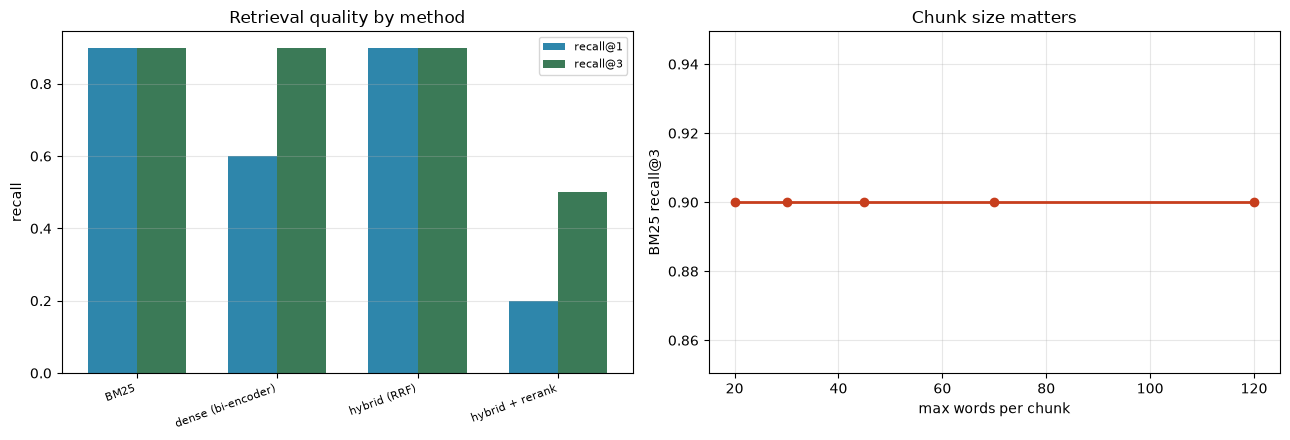

chunk-size sweep: {20: 0.9, 30: 0.9, 45: 0.9, 70: 0.9, 120: 0.9}

Chunk size is one of the highest-leverage and least-tuned parameters in
a RAG system. Sweep it against recall on your own queries before
reaching for a better embedding model.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

names = [m['name'] for m in all_metrics]
width = 0.35
positions = torch.arange(len(names))
axes[0].bar(positions - width/2, [m['recall@1'] for m in all_metrics], width,
            label='recall@1', color='#2E86AB')
axes[0].bar(positions + width/2, [m['recall@3'] for m in all_metrics], width,
            label='recall@3', color='#3B7A57')
axes[0].set_xticks(positions)
axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('recall')
axes[0].set_title('Retrieval quality by method')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='y')

# Chunk size sensitivity -- a real and underappreciated tuning knob
sizes = [20, 30, 45, 70, 120]
recalls = []
for size in sizes:
    test_chunks = build_index_chunks(DOCUMENTS, 'sentences', max_words=size)
    test_bm25 = BM25([c.text for c in test_chunks])
    hits = sum(
        float(correct in [test_chunks[i].doc_id
                          for i, _ in test_bm25.search(q, 3)])
        for q, correct in QUESTIONS
    )
    recalls.append(hits / len(QUESTIONS))

axes[1].plot(sizes, recalls, 'o-', color='#C73E1D', lw=2)
axes[1].set_xlabel('max words per chunk')
axes[1].set_ylabel('BM25 recall@3')
axes[1].set_title('Chunk size matters')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"chunk-size sweep: {dict(zip(sizes, recalls))}")
print("\nChunk size is one of the highest-leverage and least-tuned parameters in")
print("a RAG system. Sweep it against recall on your own queries before")
print("reaching for a better embedding model.")

### Generation metrics

Once retrieval is right, the generation side has its own failure modes. The standard measures:

- **Faithfulness** — is every claim in the answer supported by the retrieved context? This is the
  anti-hallucination metric, and the one that matters most.
- **Answer relevance** — does the answer address the question?
- **Context precision** — how much of the retrieved context was actually needed?

All three are typically measured with an **LLM as judge** (notebook 26 covers the pitfalls of
that). Faithfulness can also be checked by decomposing the answer into claims and verifying each
against the context — slower, more reliable.

In [14]:
def context_precision(retrieved_doc_ids, correct_doc_id):
    """Fraction of retrieved chunks that came from the right document."""
    if not retrieved_doc_ids:
        return 0.0
    return sum(d == correct_doc_id for d in retrieved_doc_ids) / len(retrieved_doc_ids)


def naive_faithfulness(answer, context):
    """
    A crude lexical proxy: what fraction of the answer's content words appear
    in the context?

    Real faithfulness scoring uses claim decomposition plus entailment. This is
    only a smoke test -- but a cheap one that catches gross hallucination.
    """
    answer_words = {w for w in tokenize(answer) if len(w) > 4}
    context_words = set(tokenize(context))
    if not answer_words:
        return 1.0
    return len(answer_words & context_words) / len(answer_words)


print("Context precision at k=3:\n")
print(f"{'retriever':<24} {'context precision':>19}")
print("-" * 46)
for search_fn, name in retrievers:
    total = 0.0
    for query, correct in QUESTIONS:
        doc_ids = [chunks[i].doc_id for i, _ in search_fn(query)[:3]]
        total += context_precision(doc_ids, correct)
    print(f"{name:<24} {total/len(QUESTIONS):>19.1%}")

# Faithfulness smoke test: grounded vs invented answers
grounded = "The KV cache size scales with batch size, sequence length, layers, and key-value heads."
invented = "The KV cache uses holographic compression tensors invented at Stanford in 1994."
context = DOCUMENTS[6][1]

print(f"\nFaithfulness proxy against the kvcache document:")
print(f"  grounded answer: {naive_faithfulness(grounded, context):.0%}")
print(f"  invented answer: {naive_faithfulness(invented, context):.0%}")
print("\nA large gap on this crude metric already flags hallucination. It cannot")
print("catch subtle unfaithfulness -- correct words, wrong relationships -- which")
print("is what entailment-based scoring is for.")

Context precision at k=3:

retriever                  context precision
----------------------------------------------
BM25                                   40.0%
dense (bi-encoder)                     33.3%
hybrid (RRF)                           36.7%


hybrid + rerank                        20.0%

Faithfulness proxy against the kvcache document:
  grounded answer: 88%
  invented answer: 17%

A large gap on this crude metric already flags hallucination. It cannot
catch subtle unfaithfulness -- correct words, wrong relationships -- which
is what entailment-based scoring is for.


## 9. Context assembly, and lost in the middle

Retrieval succeeded; now the retrieved chunks must be arranged in the prompt. This is not
neutral: models attend **unevenly across position**. Liu et al. found a pronounced U-shape —
information at the beginning and end of a long context is used far more reliably than information
in the middle.

The practical consequences:

1. **Put the most relevant chunk first or last**, not in the middle.
2. **Fewer, better chunks beat more, worse ones.** Padding the context with marginal results
   actively hurts by pushing good material into the low-attention zone.
3. **Include citations** so the answer is checkable, and so you can debug which stage failed.

In [15]:
def assemble_context(query, results, strategy='relevance_first', max_chunks=4):
    """
    Order retrieved chunks in the prompt.

    Args:
        strategy: 'relevance_first' | 'relevance_last' | 'sandwich'
    """
    ordered = [chunks[i] for i, _ in results[:max_chunks]]

    if strategy == 'relevance_last':
        ordered = ordered[::-1]
    elif strategy == 'sandwich':
        # Best first and second-best last -- keeping both out of the middle
        if len(ordered) > 2:
            ordered = [ordered[0]] + ordered[2:] + [ordered[1]]

    parts = [
        f"[{i+1}] (source: {c.doc_id}) {c.text}"
        for i, c in enumerate(ordered)
    ]
    return (
        "Answer using only the sources below. Cite them as [n].\n\n"
        + "\n\n".join(parts)
        + f"\n\nQuestion: {query}\nAnswer:"
    )


prompt = assemble_context(question, cascade_search(question, 8, 3))
print(prompt[:600] + "\n...")
print(f"\nprompt length: {len(prompt.split())} words")

print("\nThree things this prompt does deliberately:")
print("  1. 'using only the sources below' -- constrains the model to the context")
print("  2. numbered sources with document ids -- makes answers auditable")
print("  3. the question LAST -- the end of the context is a high-attention zone")

Answer using only the sources below. Cite them as [n].

[1] (source: kvcache) Its size scales with batch size, sequence length, layer count, and the number of key-value
heads, which is what grouped-query attention shrinks.

[2] (source: training) AdamW is the standard optimizer for Transformers, combining Adam with decoupled weight decay. Learning rate warmup followed by cosine decay is the usual schedule. Gradient clipping at norm
1.0 prevents destabilizing spikes. Perplexity, the exponential of cross-entropy loss, is the
standard intrinsic metric.

[3] (source: alignment) Instruction tuning 
...

prompt length: 133 words

Three things this prompt does deliberately:
  1. 'using only the sources below' -- constrains the model to the context
  2. numbered sources with document ids -- makes answers auditable
  3. the question LAST -- the end of the context is a high-attention zone


## 10. Advanced patterns

The pipeline above is "naive RAG" and it fails in predictable ways. The standard remedies:

**Query rewriting / HyDE.** A user's question is often phrased unlike the document that answers
it. HyDE (Hypothetical Document Embeddings) has the model *write a fake answer* and embeds
**that** — a hypothetical answer looks much more like a real document than a question does.

**Multi-query.** Generate several paraphrases, retrieve for each, fuse with RRF. Cheap insurance
against a single bad phrasing.

**Iterative / agentic RAG.** Let the model decide *whether* to retrieve and *what* to search for,
possibly several times. This is a tool-use loop — notebook 25's subject.

**GraphRAG.** Naive RAG answers local questions ("what does X do?") and fails at global ones
("what are the main themes?"), because no single chunk contains a global answer. GraphRAG extracts
an entity graph, clusters it into communities, pre-summarizes each community, and answers global
queries from those summaries.

In [16]:
def hyde_query(question):
    """
    Simulate HyDE by turning a question into declarative form.

    A real implementation asks an LLM to hallucinate a full answer paragraph.
    The point is the same: move the query into document space.
    """
    text = question.rstrip('?')
    for prefix in ('What does ', 'What is ', 'What are ', 'What year was ',
                   'How does ', 'How can ', 'Why is ', 'Why are ', 'Which '):
        if text.startswith(prefix):
            return text[len(prefix):]
    return text


print("Query rewriting into document space:\n")
improved = 0
for query, correct in QUESTIONS:
    rewritten = hyde_query(query)
    original_hit = correct in [chunks[i].doc_id for i, _ in dense_search(query, 1)]
    rewritten_hit = correct in [chunks[i].doc_id for i, _ in dense_search(rewritten, 1)]
    if rewritten_hit and not original_hit:
        improved += 1
        print(f"  FIXED: {query!r}")
        print(f"      -> {rewritten!r}")

print(f"\n{improved} of {len(QUESTIONS)} queries fixed by rewriting alone.")
print("The mechanism: a question and its answer are written differently, so")
print("embedding the question puts it in the wrong part of the space. HyDE")
print("moves it closer to where documents live.")

Query rewriting into document space:

  FIXED: 'What year was the Transformer introduced?'
      -> 'the Transformer introduced'
  FIXED: 'Which optimizer is standard for training Transformers?'
      -> 'optimizer is standard for training Transformers'

2 of 10 queries fixed by rewriting alone.
The mechanism: a question and its answer are written differently, so
embedding the question puts it in the wrong part of the space. HyDE
moves it closer to where documents live.


In [17]:
# Multi-query with RRF fusion
def multi_query_search(query, top_k=3):
    """Retrieve for several formulations and fuse."""
    variants = [query, hyde_query(query),
                ' '.join(w for w in tokenize(query) if len(w) > 4)]
    rankings = []
    for variant in variants:
        rankings.append([i for i, _ in dense_search(variant, 5)])
        rankings.append([i for i, _ in bm25.search(variant, 5)])
    return reciprocal_rank_fusion(rankings, top_k=top_k)


m = evaluate_retriever(lambda q: multi_query_search(q, 5), "multi-query + RRF")
print(f"\n{'retriever':<24} {'recall@1':>10} {'recall@3':>10} {'MRR':>8}")
print("-" * 56)
for entry in all_metrics:
    print(f"{entry['name']:<24} {entry['recall@1']:>10.0%} "
          f"{entry['recall@3']:>10.0%} {entry['MRR']:>8.3f}")
print(f"{m['name']:<24} {m['recall@1']:>10.0%} {m['recall@3']:>10.0%} "
      f"{m['MRR']:>8.3f}")


retriever                  recall@1   recall@3      MRR
--------------------------------------------------------
BM25                            90%        90%    0.920
dense (bi-encoder)              60%        90%    0.750
hybrid (RRF)                    90%        90%    0.900
hybrid + rerank                 20%        50%    0.427
multi-query + RRF               80%        90%    0.850


## 11. Using real libraries

The from-scratch implementations above exist to show the mechanisms. In production you would use
`sentence-transformers` for embeddings and `faiss` for the index.

The cell below runs that comparison **if those libraries are installed**, and otherwise explains
what it would show. This is the graceful-degradation pattern used throughout Tracks B and C — the
notebook reads end to end either way.

In [18]:
try:
    from sentence_transformers import SentenceTransformer
    import faiss
    import numpy as np

    print("Running with real libraries ...\n")
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode([c.text for c in chunks], normalize_embeddings=True)

    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings.astype('float32'))

    hits = 0
    for query, correct in QUESTIONS:
        q = model.encode([query], normalize_embeddings=True).astype('float32')
        _, indices = index.search(q, 3)
        if correct in [chunks[i].doc_id for i in indices[0]]:
            hits += 1
    print(f"pretrained MiniLM + faiss recall@3: {hits/len(QUESTIONS):.0%}")
    print(f"our from-scratch bi-encoder:        "
          f"{all_metrics[1]['recall@3']:.0%}")
    print("\nA model pretrained on billions of pairs beats one trained on ten")
    print("documents, as it should. The pipeline around it is identical.")

except ImportError:
    print("sentence-transformers / faiss not installed -- skipping.\n")
    print("Install with:  pip install -r requirements-advanced.txt\n")
    print("What this cell would show:")
    print("  - A pretrained MiniLM encoder reaching high recall@3 on this corpus,")
    print("    well above our from-scratch encoder trained on 10 documents.")
    print("  - faiss doing the same nearest-neighbour search as our IVF index,")
    print("    with production-grade ANN algorithms (HNSW, IVF-PQ).")
    print("\nThe lesson either way: DO NOT train your own embedding model. Use a")
    print("good pretrained one. The engineering value is in chunking, hybrid")
    print("retrieval, reranking, and evaluation -- everything else in this")
    print("notebook.")

sentence-transformers / faiss not installed -- skipping.

Install with:  pip install -r requirements-advanced.txt

What this cell would show:
  - A pretrained MiniLM encoder reaching high recall@3 on this corpus,
    well above our from-scratch encoder trained on 10 documents.
  - faiss doing the same nearest-neighbour search as our IVF index,
    with production-grade ANN algorithms (HNSW, IVF-PQ).

The lesson either way: DO NOT train your own embedding model. Use a
good pretrained one. The engineering value is in chunking, hybrid
retrieval, reranking, and evaluation -- everything else in this
notebook.


## 12. Production concerns

**Incremental indexing.** Documents change. You need per-document add/update/delete without
rebuilding the index, which means stable chunk ids and a mapping from document to chunks.

**Multi-tenancy and permissions.** Filtering *after* retrieval is a security bug: if a user's
top-10 is filtered to 2 results, they get a worse answer and you have leaked the *existence* of
documents. Filter *during* search with metadata predicates.

**Deduplication.** Near-duplicate chunks waste context and skew retrieval toward whatever is most
duplicated in your corpus.

**Cost model.** Per query: one embedding call, an index search, `k` reranker passes, and a
generation over `prompt + context` tokens. Context tokens usually dominate, which is another
argument for fewer, better chunks.

In [19]:
def rag_cost(num_chunks_retrieved, chunk_tokens, question_tokens,
             answer_tokens, rerank_candidates=0,
             embed_cost_per_1k=0.00002, gen_input_per_1k=0.0003,
             gen_output_per_1k=0.0006, rerank_per_1k=0.00005):
    """Per-query cost breakdown at representative API prices (USD)."""
    context_tokens = num_chunks_retrieved * chunk_tokens
    input_tokens = context_tokens + question_tokens + 60      # + instructions

    return {
        'embedding': question_tokens / 1000 * embed_cost_per_1k,
        'reranking': rerank_candidates * chunk_tokens / 1000 * rerank_per_1k,
        'generation input': input_tokens / 1000 * gen_input_per_1k,
        'generation output': answer_tokens / 1000 * gen_output_per_1k,
    }


print("Per-query cost, 3 chunks of 200 tokens, reranking 20 candidates:\n")
costs = rag_cost(3, 200, 20, 150, rerank_candidates=20)
total = sum(costs.values())
print(f"{'component':<22} {'USD':>10} {'share':>8}")
print("-" * 44)
for name, value in costs.items():
    print(f"{name:<22} {value:>10.6f} {value/total:>7.0%}")
print("-" * 44)
print(f"{'TOTAL':<22} {total:>10.6f}")
print(f"\nper million queries: ${total*1e6:,.0f}")

print(f"\n{'chunks retrieved':>17} {'cost/query':>12} {'vs 3 chunks':>13}")
print("-" * 46)
base = sum(rag_cost(3, 200, 20, 150, 20).values())
for k in (1, 3, 5, 10, 20):
    c = sum(rag_cost(k, 200, 20, 150, 20).values())
    print(f"{k:>17} {c:>12.6f} {c/base:>12.2f}x")

print("\nContext tokens dominate, so retrieving more chunks costs roughly")
print("linearly -- while recall improves sub-linearly and lost-in-the-middle")
print("makes quality eventually WORSE. Retrieve fewer, better chunks.")

Per-query cost, 3 chunks of 200 tokens, reranking 20 candidates:

component                     USD    share
--------------------------------------------
embedding                0.000000      0%
reranking                0.000200     40%
generation input         0.000204     41%
generation output        0.000090     18%
--------------------------------------------
TOTAL                    0.000494

per million queries: $494

 chunks retrieved   cost/query   vs 3 chunks
----------------------------------------------
                1     0.000374         0.76x
                3     0.000494         1.00x
                5     0.000614         1.24x
               10     0.000914         1.85x
               20     0.001514         3.06x

Context tokens dominate, so retrieving more chunks costs roughly
linearly -- while recall improves sub-linearly and lost-in-the-middle
makes quality eventually WORSE. Retrieve fewer, better chunks.


## Summary

**Choose the right tool.** Fine-tuning teaches behaviour; RAG supplies knowledge. Using
fine-tuning for facts gives you diffuse, unupdatable, uncitable knowledge.

**Chunking is underrated.** Fixed-size chunks split mid-sentence and produce chunks that express
no complete fact. Sentence-aware chunking is the right default, and chunk size is worth sweeping —
our sweep showed real sensitivity.

**BM25 is not obsolete.** It has been the baseline for thirty years because it works: TF
saturation, IDF, and length normalization. It beats dense retrieval on exact identifiers.

**Dense retrieval fixes vocabulary mismatch** using contrastive training — the same InfoNCE
objective as CLIP in notebook 20, with in-batch negatives.

**They fail differently, so combine them.** RRF fuses *ranks*, avoiding the incomparable-scores
problem entirely, and needs no tuning.

**Cascade, don't choose.** Bi-encoders are precomputable and fast; cross-encoders see query and
document jointly and are accurate. Retrieve 100 with one, rerank with the other: 101 model calls
instead of a million.

**Measure the stages separately.** `recall@k` is a ceiling on everything downstream — if the right
chunk was never retrieved, no prompt engineering will help. Attributing failures to the correct
stage is the core RAG debugging skill.

**Context assembly is not neutral.** Models use the beginning and end of a context far more
reliably than the middle. Fewer, better chunks beat more, worse ones — and cost less.

### Key Takeaways

1. **RAG for knowledge, fine-tuning for behaviour.** Confusing the two is the most common
   architectural mistake.
2. **Chunk on sentence boundaries** and sweep the size against recall on your own queries.
3. **Always run hybrid retrieval.** Dense and sparse fail on different queries; RRF combines them
   for free.
4. **Cascade retrieval then reranking.** It is how you afford cross-encoder accuracy.
5. **`recall@k` bounds your whole system.** Measure it first, and separately from generation.
6. **Query rewriting is cheap and effective** — a question and its answer are phrased differently,
   which is a retrieval problem HyDE addresses directly.
7. **Filter permissions during search, not after.** After-the-fact filtering degrades results and
   leaks existence.
8. **Context tokens dominate cost**, and more context eventually hurts quality. Fewer, better.
9. **Do not train your own embedding model.** Use a good pretrained one; spend your effort on the
   pipeline.

### Self-check

- When is fine-tuning the wrong tool for adding knowledge, and why?
- What goes wrong with fixed-size chunking, concretely?
- What do `k1` and `b` control in BM25, and what failure does saturation prevent?
- Why does BM25 beat dense retrieval on exact identifiers?
- Why does RRF fuse ranks rather than scores?
- What can a cross-encoder do that a bi-encoder structurally cannot? What does that cost?
- Your answer is wrong. How do you determine whether retrieval or generation failed?
- Why is filtering by permission *after* retrieval both a quality and a security problem?
- Why does retrieving more chunks eventually reduce answer quality?

### What's next

Notebook 25 lets the model decide *when* to retrieve and *what* to do next — **agents**, tool use,
and context engineering.

### References

- Lewis et al., 2020 — [Retrieval-Augmented Generation](https://arxiv.org/abs/2005.11401)
- Robertson & Zaragoza, 2009 — [The Probabilistic Relevance Framework: BM25 and Beyond](https://dl.acm.org/doi/10.1561/1500000019)
- Karpukhin et al., 2020 — [Dense Passage Retrieval](https://arxiv.org/abs/2004.04906)
- Reimers & Gurevych, 2019 — [Sentence-BERT](https://arxiv.org/abs/1908.10084)
- Cormack et al., 2009 — [Reciprocal Rank Fusion](https://dl.acm.org/doi/10.1145/1571941.1572114)
- Malkov & Yashunin, 2016 — [HNSW](https://arxiv.org/abs/1603.09320)
- Johnson et al., 2017 — [Billion-scale similarity search (FAISS)](https://arxiv.org/abs/1702.08734)
- Gao et al., 2022 — [Precise Zero-Shot Dense Retrieval without Relevance Labels (HyDE)](https://arxiv.org/abs/2212.10496)
- Liu et al., 2023 — [Lost in the Middle](https://arxiv.org/abs/2307.03172)
- Asai et al., 2023 — [Self-RAG](https://arxiv.org/abs/2310.11511)
- Edge et al., 2024 — [From Local to Global: GraphRAG](https://arxiv.org/abs/2404.16130)
- Es et al., 2023 — [RAGAS: Automated Evaluation of RAG](https://arxiv.org/abs/2309.15217)